In [34]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/spectra_log.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded data from {file_path}.")
display(df.head())

Successfully loaded data from /content/spectra_log.csv.


,Timestamp_ms,IntegrationTime_us,AutoExposure,LED_State,Comment,Max_ADC,P0,P1,P2,P3,...,P278,P279,P280,P281,P282,P283,P284,P285,P286,P287
0,79095,1000000,ON,ON,Turmeric,673,355,359,356,358,...,279,286,286,287,287,284,282,286,280,286
1,139462,1000000,ON,ON,Turmeric,703,359,361,357,359,...,283,292,293,284,288,286,285,286,283,291
2,199832,1000000,ON,ON,Turmeric,719,357,357,360,363,...,282,291,289,290,276,283,288,298,286,290
3,260199,1000000,ON,ON,Turmeric,729,366,366,361,366,...,277,291,293,290,293,285,287,286,284,293
4,320561,1000000,ON,ON,Turmeric,731,368,359,356,364,...,287,289,288,288,292,287,289,290,285,289


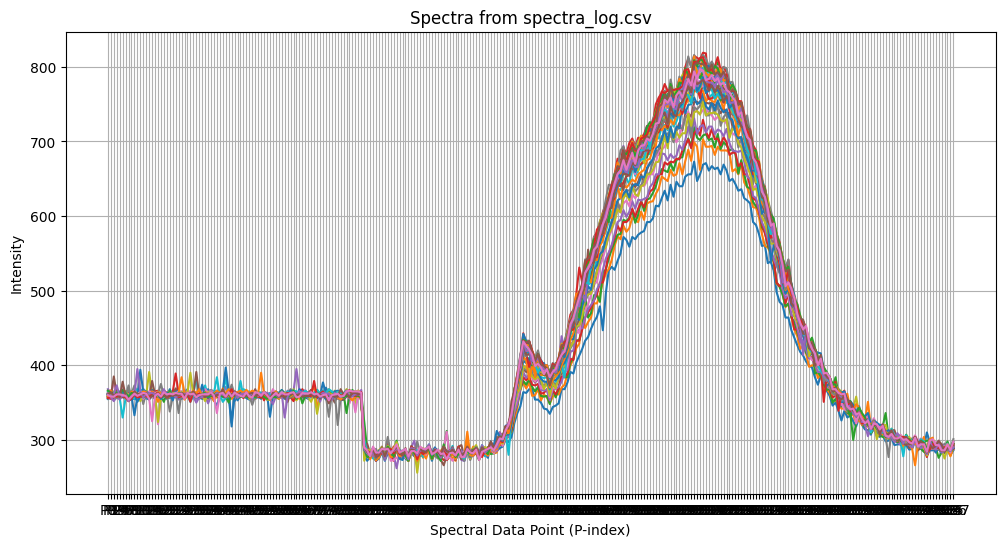

In [35]:
spectral_columns = [col for col in df.columns if col.startswith('P') and col[1:].isdigit()]

plt.figure(figsize=(12, 6))
for index, row in df.iterrows():
    plt.plot(spectral_columns, row[spectral_columns], label=f'Spectrum {index}')

plt.xlabel('Spectral Data Point (P-index)')
plt.ylabel('Intensity')
plt.title('Spectra from spectra_log.csv')
# To avoid cluttering with too many labels, only show legend if there are few spectra
if len(df) <= 10:
    plt.legend()
plt.grid(True)
plt.show()

In [36]:
import re
import numpy as np

# 1. Calibration coefficients for Serial 21A02875
A0 = 3.086965198E+02
B1 = 2.718912698E+00
B2 = -1.434471882E-03
B3 = -5.759067943E-06
B4 = 3.250344320E-09
B5 = 1.237572658E-11

def pixel_to_wavelength(pix_rel):
    return (A0 +
            B1 * pix_rel +
            B2 * (pix_rel ** 2) +
            B3 * (pix_rel ** 3) +
            B4 * (pix_rel ** 4) +
            B5 * (pix_rel ** 5))

In [37]:
# 2. Separate the 87 shielded dark pixels (P0 to P86) from active pixels (P87 onwards)
dark_cols = [f'P{i}' for i in range(87) if f'P{i}' in df.columns]
active_cols = sorted(
    [col for col in df.columns if re.match(r'^P\d+$', col) and int(col[1:]) >= 87],
    key=lambda x: int(x[1:])
)

# 3. Calculate dark baseline from P0-P86 and subtract from active pixels only
dark_baseline = df[dark_cols].mean(axis=1) if dark_cols else 0

df_corrected = df.copy()
for col in active_cols:
    df_corrected[col] = df[col] - dark_baseline

In [38]:
# 4. Compute wavelengths using the relative active index (P87 -> index 0 starts in UV)
active_pixel_indices = np.array([int(col[1:]) - 87 for col in active_cols], dtype=float)
wavelengths = pixel_to_wavelength(active_pixel_indices)



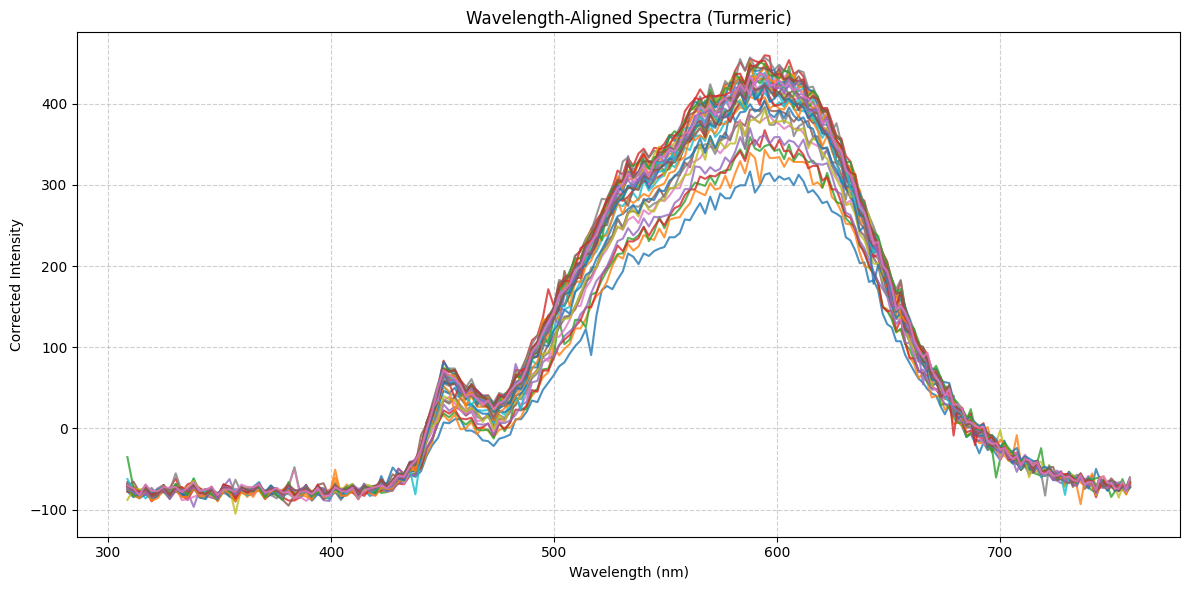

In [39]:
plt.figure(figsize=(12, 6))

for index, row in df_corrected.iterrows():
    plt.plot(wavelengths, row[active_cols], alpha=0.8, label=f'Spectrum {index}' if len(df) <= 10 else "")

plt.xlabel('Wavelength (nm)')
plt.ylabel('Corrected Intensity')
plt.title('Wavelength-Aligned Spectra (Turmeric)')

# Only show legend if there are 10 or fewer spectra to avoid clutter
if len(df) <= 10:
    plt.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

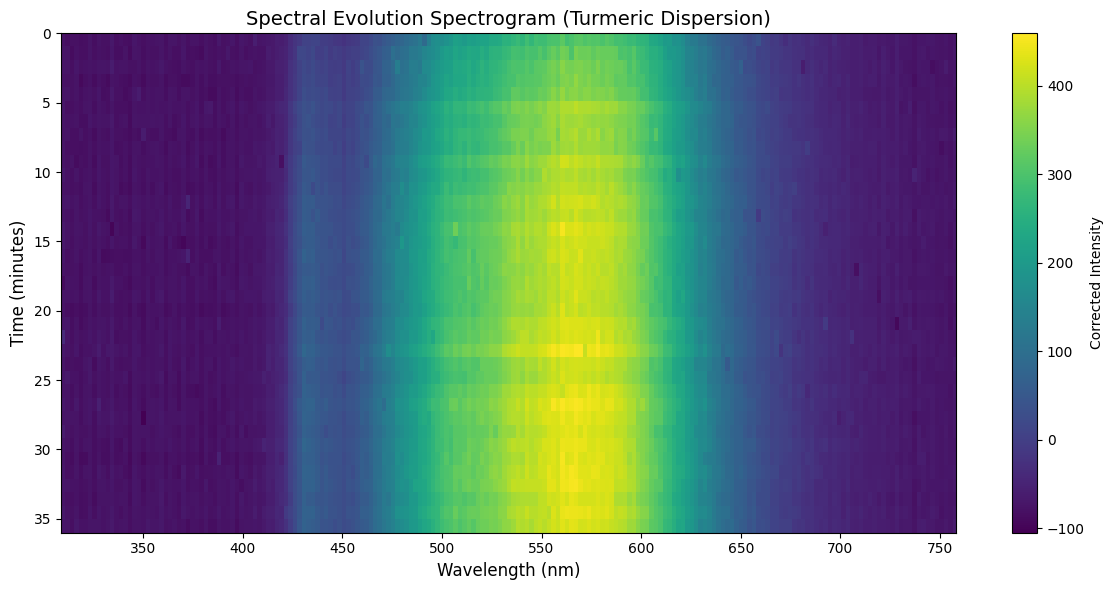

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Define time axis (assuming 1 spectrum every 60 seconds)
time_minutes = np.arange(len(df_corrected)) * 1.0
intensity_matrix = df_corrected[active_cols].values

plt.figure(figsize=(12, 6))

# Plot heatmap with wavelengths on X-axis and time on Y-axis
im = plt.imshow(
    intensity_matrix,
    aspect='auto',
    extent=[wavelengths[0], wavelengths[-1], time_minutes[-1], time_minutes[0]],
    cmap='viridis'
)

# Add colorbar and clearly label axes
cbar = plt.colorbar(im)
cbar.set_label('Corrected Intensity')

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Time (minutes)', fontsize=12)
plt.title('Spectral Evolution Spectrogram (Turmeric Dispersion)', fontsize=14)

plt.grid(False) # Heatmaps look cleaner without a grid overlay
plt.tight_layout()
plt.show()

=== Automated Dispersion Stability Report ===
Sedimentation Rate: 2.024% change per minute
 -> STATUS: Suspension is stable against heavy sedimentation.
Agglomeration Slope: -0.15762 units/min
 -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.


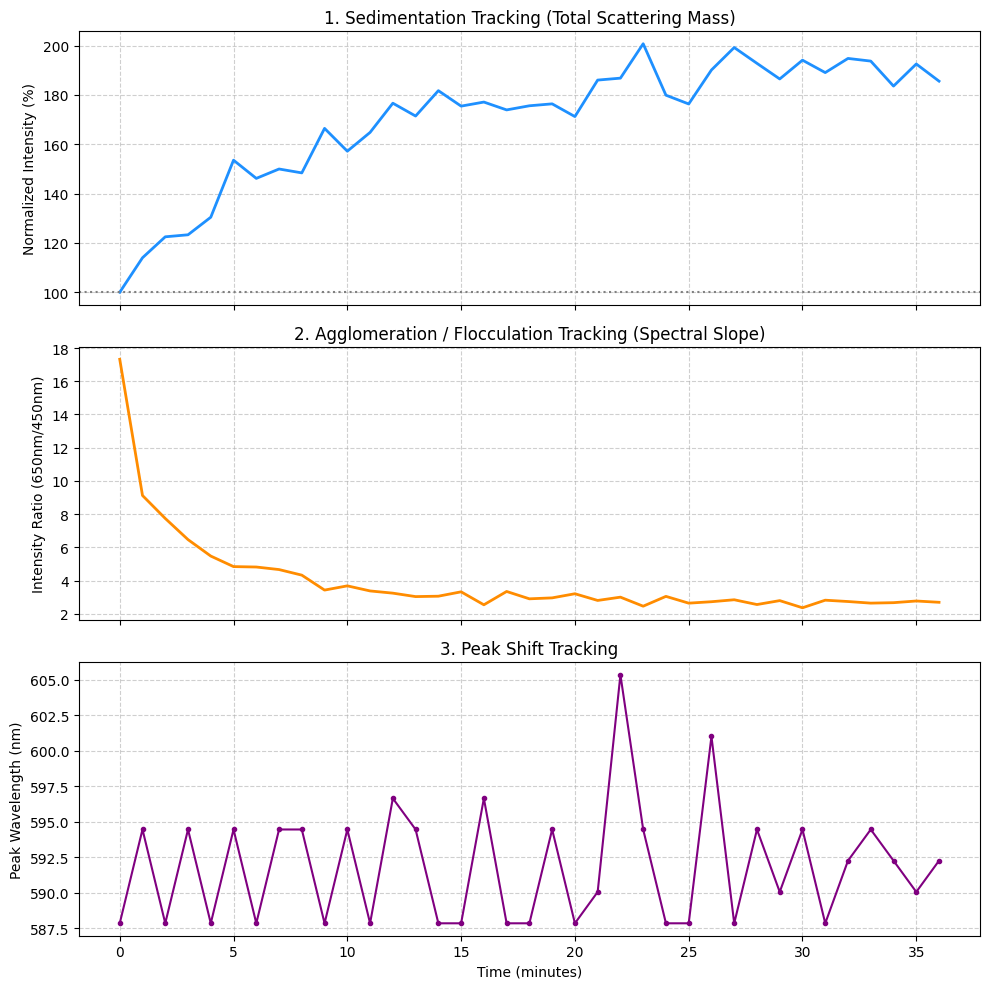

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def analyze_dispersion_stability(df_corrected, active_cols, wavelengths, time_step_seconds=60):
    """
    Analyzes a time-series spectral log for sedimentation, agglomeration, and flocculation.
    """
    # 1. Setup Time Axis (in minutes)
    time_minutes = np.arange(len(df_corrected)) * (time_step_seconds / 60.0)
    intensity_matrix = df_corrected[active_cols].values

    # 2. Metric A: Sedimentation (Total Integrated Intensity)
    total_intensity = df_corrected[active_cols].sum(axis=1)
    sedimentation_norm = (total_intensity / total_intensity.iloc[0]) * 100 # Normalized to % of initial

    # 3. Metric B: Agglomeration/Particle Growth (Spectral Slope / Ratio)
    idx_450 = np.argmin(np.abs(wavelengths - 450))
    idx_650 = np.argmin(np.abs(wavelengths - 650))

    col_450 = active_cols[idx_450]
    col_650 = active_cols[idx_650]
    spectral_ratio = df_corrected[col_650] / df_corrected[col_450]

    # 4. Metric C: Peak Wavelength Shift
    max_idx_cols = df_corrected[active_cols].idxmax(axis=1)
    peak_wavelengths = [wavelengths[active_cols.index(col)] for col in max_idx_cols]

    # 5. Linear Trends (Rates of Change)
    sed_slope, _, _, _, _ = linregress(time_minutes, sedimentation_norm)
    ratio_slope, _, _, _, _ = linregress(time_minutes, spectral_ratio)

    print("=== Automated Dispersion Stability Report ===")
    print(f"Sedimentation Rate: {sed_slope:.3f}% change per minute")
    if sed_slope < -0.5:
        print(" -> ALERT: Significant sedimentation detected (particles dropping out).")
    else:
        print(" -> STATUS: Suspension is stable against heavy sedimentation.")

    print(f"Agglomeration Slope: {ratio_slope:.5f} units/min")
    if abs(ratio_slope) > 0.001:
        print(" -> ALERT: Spectral slope shifting, indicating possible particle growth/flocculation.")
    else:
        print(" -> STATUS: No major particle size evolution detected.")

    # 6. Plotting Dashboard for Future Tests
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    # Panel 1: Sedimentation Trend
    axes[0].plot(time_minutes, sedimentation_norm, color='dodgerblue', lw=2)
    axes[0].set_ylabel('Normalized Intensity (%)')
    axes[0].set_title('1. Sedimentation Tracking (Total Scattering Mass)')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].axhline(100, color='gray', linestyle=':')

    # Panel 2: Agglomeration / Size Ratio Trend
    axes[1].plot(time_minutes, spectral_ratio, color='darkorange', lw=2)
    axes[1].set_ylabel('Intensity Ratio (650nm/450nm)')
    axes[1].set_title('2. Agglomeration / Flocculation Tracking (Spectral Slope)')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Panel 3: Peak Position Shift
    axes[2].plot(time_minutes, peak_wavelengths, color='purple', marker='.', linestyle='-')
    axes[2].set_xlabel('Time (minutes)')
    axes[2].set_ylabel('Peak Wavelength (nm)')
    axes[2].set_title('3. Peak Shift Tracking')
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run the function now that it's uncommented
analyze_dispersion_stability(df_corrected, active_cols, wavelengths)